# Lab 5: Hyperspectral Data & water quality analysis


The structure of this notebook:
- Imports, User Configuration, Functions
- False Colour composite & water quality indices (Airbone data) (Task 3 - part I)
- Download of Sentinel-2 data & calculation and comparison of same indices (Task 3 - part II)
- SAM on Sentinel-2 data

In [24]:
from pathlib import Path
from datetime import datetime, timedelta
import json
import re
import os
import sys

if sys.platform == "win32":
    try:
        import rasterio

        rasterio_proj = Path(rasterio.__file__).resolve().parent / "proj_data"
        if rasterio_proj.exists():
            os.environ["PROJ_DATA"] = str(rasterio_proj)
            os.environ["PROJ_LIB"] = str(rasterio_proj)
        else:
            import pyproj

            proj_dir = pyproj.datadir.get_data_dir()
            os.environ["PROJ_DATA"] = proj_dir
            os.environ["PROJ_LIB"] = proj_dir
    except Exception:
        pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spectral.io.envi as envi

from pystac_client import Client
import planetary_computer as pc
from odc.stac import stac_load

plt.style.use("seaborn-v0_8-whitegrid")

In [25]:
# -------------------------
# User configuration
# -------------------------
AIRBORNE_HDR = Path("data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr")
AIRBORNE_ACQ_DATE = "2025-06-17"

# Sentinel-2 search window around airborne date.
S2_SEARCH_HALF_WINDOW_DAYS = 12

# Optional processing subset in pixel coordinates:
# (row_start, row_end, col_start, col_end)
AIRBORNE_SUBSET = None

# For display only: downsample factor for plots.
DISPLAY_STRIDE = 2
SPECTRAL_LIBRARY_DIR = Path("data/signatures")

# Calibration settings (S2 -> Airborne)
CALIBRATION_SAMPLE_N = 30000
CALIBRATION_ROBUST_PERCENTILES = (2, 98)

# Water mask thresholds
AIR_NIR_WATER_THRESHOLD = 0.075

# Sentinel-2 only
S2_NIR_WATER_THRESHOLD = 0.15
S2_NDWI_THRESHOLD = 0.00
S2_NIR_WATER_THRESHOLD_RELAX = 0.20
S2_NDWI_THRESHOLD_RELAX = -0.15

In [26]:
def parse_airborne_date_from_name(path: Path):
    """Try to parse date tokens from filename (YYYYMMDD or YYMMDD)."""
    stem = path.stem

    m8 = re.search(r"(20\d{6})", stem)
    if m8:
        try:
            return datetime.strptime(m8.group(1), "%Y%m%d").date()
        except ValueError:
            pass

    m6 = re.search(r"(\d{6})", stem)
    if m6:
        token = m6.group(1)
        try:
            return datetime.strptime(token, "%y%m%d").date()
        except ValueError:
            pass

    return None


def parse_map_info_envi(meta):
    """Extract ENVI map info fields needed for bounds."""
    info = meta.get("map info")
    if info is None:
        raise ValueError("No 'map info' in ENVI metadata.")

    if isinstance(info, str):
        inner = info.strip("{}")
        parts = [p.strip() for p in inner.split(",")]
    else:
        parts = [str(p).strip() for p in info]

    # [proj_name, ref_col, ref_row, x_ref, y_ref, x_size, y_size, ...]
    x_ref = float(parts[3])
    y_ref = float(parts[4])
    x_size = float(parts[5])
    y_size = float(parts[6])
    return x_ref, y_ref, x_size, y_size


def compute_bounds(meta, ncols, nrows):
    """Return (xmin, ymin, xmax, ymax) from ENVI map info and dimensions."""
    x_ref, y_ref, x_size, y_size = parse_map_info_envi(meta)
    xmin = x_ref
    xmax = x_ref + ncols * x_size
    ymax = y_ref
    ymin = y_ref - nrows * y_size
    return xmin, ymin, xmax, ymax


def nearest_band_index(wavelengths, target_nm):
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def robust_stretch(arr, p_low=2, p_high=98):
    arr = arr.astype(np.float32)
    p2, p98 = np.nanpercentile(arr, [p_low, p_high])
    if p98 <= p2:
        return np.zeros_like(arr)
    out = np.clip((arr - p2) / (p98 - p2), 0, 1)
    return np.nan_to_num(out, nan=0.0)


def safe_div(a, b):
    out = np.full_like(a, np.nan, dtype=np.float32)
    m = np.isfinite(a) & np.isfinite(b) & (np.abs(b) > 1e-12)
    out[m] = a[m] / b[m]
    return out


def normalized_diff(a, b):
    return safe_div(a - b, a + b)


def otsu_threshold(values, bins=256):
    """Simple Otsu threshold for 1D finite array."""
    v = values[np.isfinite(values)]
    if v.size < 10:
        return np.nan
    vmin, vmax = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        return np.nan

    hist, edges = np.histogram(v, bins=bins, range=(vmin, vmax))
    centers = (edges[:-1] + edges[1:]) / 2
    prob = hist.astype(np.float64) / max(hist.sum(), 1)

    w0 = np.cumsum(prob)
    w1 = 1.0 - w0
    mu = np.cumsum(prob * centers)
    mu_t = mu[-1]

    sigma_b2 = np.zeros_like(centers)
    valid = (w0 > 1e-12) & (w1 > 1e-12)
    sigma_b2[valid] = ((mu_t * w0[valid] - mu[valid]) ** 2) / (w0[valid] * w1[valid])

    i = int(np.nanargmax(sigma_b2))
    return float(centers[i])


def build_water_mask(green, nir, blue=None, red=None):
    """Robust water mask: adaptive NDWI + low NIR (+ optional blue/red check)."""
    ndwi = normalized_diff(green, nir)
    valid = np.isfinite(ndwi) & np.isfinite(green) & np.isfinite(nir)
    if not np.any(valid):
        return np.zeros_like(green, dtype=bool), ndwi, np.nan

    thr_otsu = otsu_threshold(ndwi[valid])
    # Keep a conservative lower bound; pure NDWI>0 is often too optimistic/noisy.
    thr = max(0.05, thr_otsu if np.isfinite(thr_otsu) else 0.05)

    nir_p35 = np.nanpercentile(nir[valid], 35)
    base = valid & (ndwi > thr) & (nir < nir_p35)

    # Optional spectral sanity rule for water tone in VIS.
    if blue is not None and red is not None:
        vis_ok = np.isfinite(blue) & np.isfinite(red) & (blue >= 0.9 * red)
        base &= vis_ok

    # If mask is unrealistically small, relax criteria automatically.
    frac = np.mean(base)
    if frac < 0.002:  # <0.2% scene
        thr_relaxed = max(0.0, thr - 0.05)
        nir_p50 = np.nanpercentile(nir[valid], 50)
        base = valid & (ndwi > thr_relaxed) & (nir < nir_p50)
        thr = thr_relaxed

    return base, ndwi, thr


def read_band_subset(img_obj, band_idx, row0, row1, col0, col1, ignore):
    """Read a single band, then crop to subset (keeps memory low)."""
    arr = img_obj.read_band(int(band_idx)).astype(np.float32)
    arr = arr[row0:row1, col0:col1]
    arr[arr >= ignore] = np.nan
    arr[arr < 0] = np.nan
    return arr


def stats_on_mask(arr, mask, name):
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        return {"index": name, "n": 0, "mean": np.nan, "std": np.nan, "p10": np.nan, "p50": np.nan, "p90": np.nan}
    return {
        "index": name,
        "n": int(vals.size),
        "mean": float(np.nanmean(vals)),
        "std": float(np.nanstd(vals)),
        "p10": float(np.nanpercentile(vals, 10)),
        "p50": float(np.nanpercentile(vals, 50)),
        "p90": float(np.nanpercentile(vals, 90)),
    }


def block_reduce_mean(arr2d, factor):
    """Downsample 2D array by integer factor using mean (ignores NaNs)."""
    if factor == 1:
        return arr2d
    h, w = arr2d.shape
    h2 = (h // factor) * factor
    w2 = (w // factor) * factor
    a = arr2d[:h2, :w2]
    a = a.reshape(h2 // factor, factor, w2 // factor, factor)
    return np.nanmean(a, axis=(1, 3))

In [27]:
# -------------------------
# Load airborne
# -------------------------
img = envi.open(str(AIRBORNE_HDR))
meta = img.metadata

wavelengths = np.array([float(w) for w in meta["wavelength"]], dtype=np.float32)
ignore_value = float(meta.get("data ignore value", 15000))

nrows, ncols, nbands = img.nrows, img.ncols, img.nbands
print(f"Loaded airborne: {AIRBORNE_HDR.name}")
print(f"Airborne shape: {nrows} x {ncols} x {nbands}")

acq_date = AIRBORNE_ACQ_DATE
if acq_date is not None:
    acq_date = datetime.strptime(acq_date, "%Y-%m-%d").date()
else:
    acq_date = parse_airborne_date_from_name(AIRBORNE_HDR)
print("Airborne acquisition date:", acq_date if acq_date else "not detected (set AIRBORNE_ACQ_DATE)")

xmin, ymin, xmax, ymax = compute_bounds(meta, ncols=ncols, nrows=nrows)
print("Airborne bounds:", (xmin, ymin, xmax, ymax))

if AIRBORNE_SUBSET is None:
    r0, r1, c0, c1 = 0, nrows, 0, ncols
else:
    r0, r1, c0, c1 = AIRBORNE_SUBSET
print("Processing subset:", (r0, r1, c0, c1))

# Band selection
b_idx = {
    "blue_480": nearest_band_index(wavelengths, 480),
    "blue_490": nearest_band_index(wavelengths, 490),
    "green": nearest_band_index(wavelengths, 560),
    "red_660": nearest_band_index(wavelengths, 660),
    "red_665": nearest_band_index(wavelengths, 665),
    "rededge": nearest_band_index(wavelengths, 705),
    "nir_800": nearest_band_index(wavelengths, 800),
    "nir_842": nearest_band_index(wavelengths, 842),
    "nir_740": nearest_band_index(wavelengths, 740),
    "nir_865": nearest_band_index(wavelengths, 865),
    "swir1610": nearest_band_index(wavelengths, 1610),
    "swir2190": nearest_band_index(wavelengths, 2190),
}
print("Selected hyperspectral band indices:", b_idx)

R480 = read_band_subset(img, b_idx["blue_480"], r0, r1, c0, c1, ignore_value)
R490 = read_band_subset(img, b_idx["blue_490"], r0, r1, c0, c1, ignore_value)
R560 = read_band_subset(img, b_idx["green"], r0, r1, c0, c1, ignore_value)
R660 = read_band_subset(img, b_idx["red_660"], r0, r1, c0, c1, ignore_value)
R665 = read_band_subset(img, b_idx["red_665"], r0, r1, c0, c1, ignore_value)
R705 = read_band_subset(img, b_idx["rededge"], r0, r1, c0, c1, ignore_value)
R800 = read_band_subset(img, b_idx["nir_800"], r0, r1, c0, c1, ignore_value)
R842 = read_band_subset(img, b_idx["nir_842"], r0, r1, c0, c1, ignore_value)
R740 = read_band_subset(img, b_idx["nir_740"], r0, r1, c0, c1, ignore_value)
R865 = read_band_subset(img, b_idx["nir_865"], r0, r1, c0, c1, ignore_value)
R1610 = read_band_subset(img, b_idx["swir1610"], r0, r1, c0, c1, ignore_value)
R2190 = read_band_subset(img, b_idx["swir2190"], r0, r1, c0, c1, ignore_value)

print("Loaded airborne bands with shape:", R490.shape)

Loaded airborne: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Airborne shape: 4300 x 2001 x 456
Airborne acquisition date: 2025-06-17
Airborne bounds: (6509736.0, 5576412.0, 6511737.0, 5580712.0)
Processing subset: (0, 4300, 0, 2001)
Selected hyperspectral band indices: {'blue_480': 21, 'blue_490': 24, 'green': 46, 'red_660': 77, 'red_665': 78, 'rededge': 91, 'nir_800': 121, 'nir_842': 134, 'nir_740': 102, 'nir_865': 141, 'swir1610': 292, 'swir2190': 398}
Loaded airborne bands with shape: (4300, 2001)


(np.float64(-0.5), np.float64(1000.5), np.float64(2149.5), np.float64(-0.5))

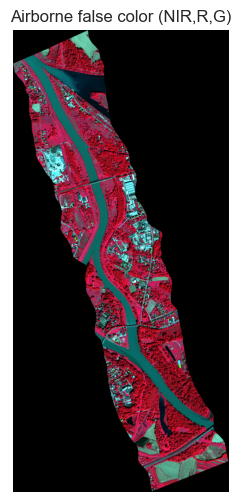

In [28]:
# -------------------------
# False-color composites (airborne)
# -------------------------
# A: NIR/Red/Green
fca = np.dstack([
    robust_stretch(R842),
    robust_stretch(R665),
    robust_stretch(R560),
])

s = max(int(DISPLAY_STRIDE), 1)
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(fca[::s, ::s, :])
ax.set_title("Airborne false color (NIR,R,G)")
ax.axis("off")

Airborne NIR water threshold: 0.075
Airborne water fraction: 7.12%


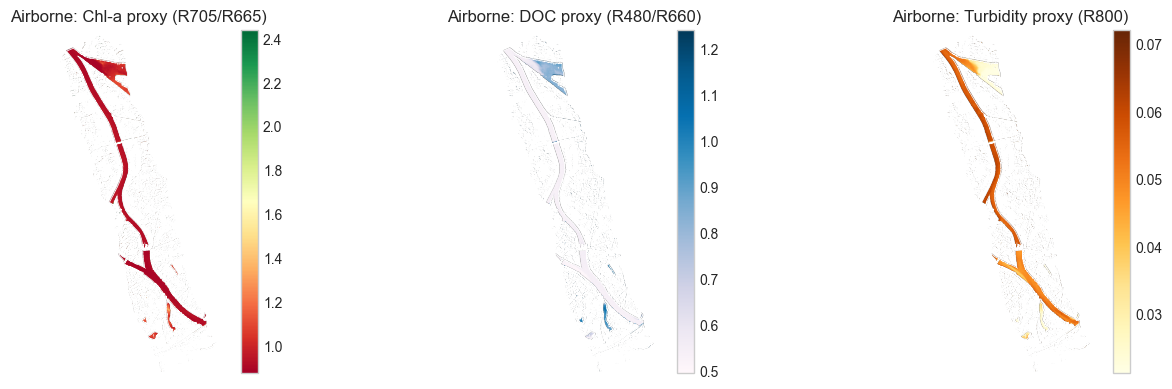

In [29]:
# -------------------------
# Airborne water-quality proxy indices
# -------------------------
# Formulas:
# - Chl-a proxy: R705 / R665
# - Turbidity proxy: R800
# - DOC proxy: R480 / R660

with np.errstate(divide='ignore', invalid='ignore'):
    chl_a_proxy_air = safe_div(R705, R665)
    _doc_proxy_air = safe_div(R480, R660)
    _turb_proxy_air = R800.astype(np.float32)

# Airborne water mask.
valid_nir = np.isfinite(R800) & (R800 > 1e-4)
water_mask_air = valid_nir & (R800 < AIR_NIR_WATER_THRESHOLD)

print(f"Airborne NIR water threshold: {AIR_NIR_WATER_THRESHOLD:.3f}")
print(f"Airborne water fraction: {100 * water_mask_air.mean():.2f}%")

chl_a_map_air = np.where(water_mask_air, chl_a_proxy_air, np.nan)
doc_map_air = np.where(water_mask_air, _doc_proxy_air, np.nan)
turb_map_air = np.where(water_mask_air, _turb_proxy_air, np.nan)

s = max(int(DISPLAY_STRIDE), 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (arr, ttl, cmap) in enumerate([
    (chl_a_map_air, "Airborne: Chl-a proxy (R705/R665)", "RdYlGn"),
    (doc_map_air, "Airborne: DOC proxy (R480/R660)", "PuBu"),
    (turb_map_air, "Airborne: Turbidity proxy (R800)", "YlOrBr"),
]):
    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        vmin, vmax = np.nanpercentile(vals, [2, 98])
    else:
        vmin, vmax = None, None

    im = ax[i].imshow(arr[::s, ::s], cmap=cmap, vmin=vmin, vmax=vmax)
    ax[i].contour(water_mask_air[::s, ::s], levels=[0.5], colors="white", linewidths=0.5)
    ax[i].set_title(ttl)
    ax[i].axis("off")
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)
plt.tight_layout()

In [30]:
# -------------------------
# Sentinel-2 download
# -------------------------
# IMPORTANT:
# - The ENVI header bounds we computed (xmin/ymin/xmax/ymax) are in the airborne CRS (meters).
# - STAC search expects bbox in WGS84 lon/lat (EPSG:4326).

import rasterio
from pyproj import Transformer, CRS as PyCRS

if acq_date is None:
    raise ValueError("Set AIRBORNE_ACQ_DATE = 'YYYY-MM-DD' (date not detected from filename).")

start = acq_date - timedelta(days=S2_SEARCH_HALF_WINDOW_DAYS)
end = acq_date + timedelta(days=S2_SEARCH_HALF_WINDOW_DAYS)

time_range = f"{start.isoformat()}T00:00:00Z/{end.isoformat()}T23:59:59Z"

# Read CRS + bounds directly from airborne raster.
def _find_airborne_raster_path(hdr_path: Path):
    candidates = [
        hdr_path.with_suffix('.bsq'),
        hdr_path.with_suffix('.img'),
        hdr_path.with_suffix('.dat'),
        hdr_path,  # in some cases rasterio can open using .hdr directly
    ]
    for p in candidates:
        if p.exists():
            try:
                with rasterio.open(str(p)) as _:
                    return p
            except Exception:
                continue
    raise FileNotFoundError(f"Could not find an airborne raster next to {hdr_path}")

airborne_raster_path = _find_airborne_raster_path(AIRBORNE_HDR)
with rasterio.open(str(airborne_raster_path)) as src:
    airborne_crs = src.crs
    airborne_bounds = src.bounds

if airborne_crs is None:
    raise ValueError("Airborne raster has no CRS. Cannot transform bounds for STAC search.")

minx, miny, maxx, maxy = airborne_bounds
src_crs = PyCRS.from_wkt(airborne_crs.to_wkt())
dst_crs = PyCRS.from_proj4("+proj=longlat +datum=WGS84 +no_defs +type=crs")
transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

corners_x = [minx, maxx, maxx, minx]
corners_y = [miny, miny, maxy, maxy]
lon, lat = transformer.transform(corners_x, corners_y)

xmin_ll, xmax_ll = float(np.min(lon)), float(np.max(lon))
ymin_ll, ymax_ll = float(np.min(lat)), float(np.max(lat))
bbox_lonlat = [xmin_ll, ymin_ll, xmax_ll, ymax_ll]

print("Using airborne raster:", airborne_raster_path)
print("STAC bbox (lon/lat):", bbox_lonlat)

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_lonlat,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 30}},
)
items = list(search.items())
if not items:
    raise RuntimeError("No Sentinel-2 scenes found for the date window / bbox.")

items_sorted = sorted(
    items,
    key=lambda it: (
        abs(it.datetime.date() - acq_date),
        it.properties.get("eo:cloud_cover", 1000),
    ),
)

best_item = pc.sign(items_sorted[0])
print("Selected Sentinel-2 item:", best_item.id)
print("Datetime:", best_item.datetime)
print("Cloud cover:", best_item.properties.get("eo:cloud_cover"))

# Load bands using native Sentinel names.
# B02..B8A at 10 m; B11/B12 native 20 m are resampled to 10 m by odc.stac.
s2 = stac_load(
    [best_item],
    bands=["B02", "B03", "B04", "B05", "B8A", "B11", "B12"],
    bbox=bbox_lonlat,
    resolution=10,
    chunks={},
).isel(time=0)

print(s2)

Using airborne raster: data\images\221000_Odra_HS_Blok_A_008_VS_join_atm.bsq
STAC bbox (lon/lat): [18.136726219401297, 50.3234799567054, 18.16496073322807, 50.36217592715419]
Selected Sentinel-2 item: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401
Datetime: 2025-06-15 09:50:51.025000+00:00
Cloud cover: 0.461973
<xarray.Dataset> Size: 3MB
Dimensions:      (y: 440, x: 220)
Coordinates:
  * y            (y) float64 4kB 5.584e+06 5.584e+06 ... 5.579e+06 5.579e+06
  * x            (x) float64 2kB 7.231e+05 7.231e+05 ... 7.253e+05 7.253e+05
    spatial_ref  int32 4B 32633
    time         datetime64[us] 8B 2025-06-15T09:50:51.025000
Data variables:
    B02          (y, x) float32 387kB dask.array<chunksize=(440, 220), meta=np.ndarray>
    B03          (y, x) float32 387kB dask.array<chunksize=(440, 220), meta=np.ndarray>
    B04          (y, x) float32 387kB dask.array<chunksize=(440, 220), meta=np.ndarray>
    B05          (y, x) float32 387kB dask.array<chunksize=(440, 220), meta=n

Sentinel-2 water fraction: 5.11%


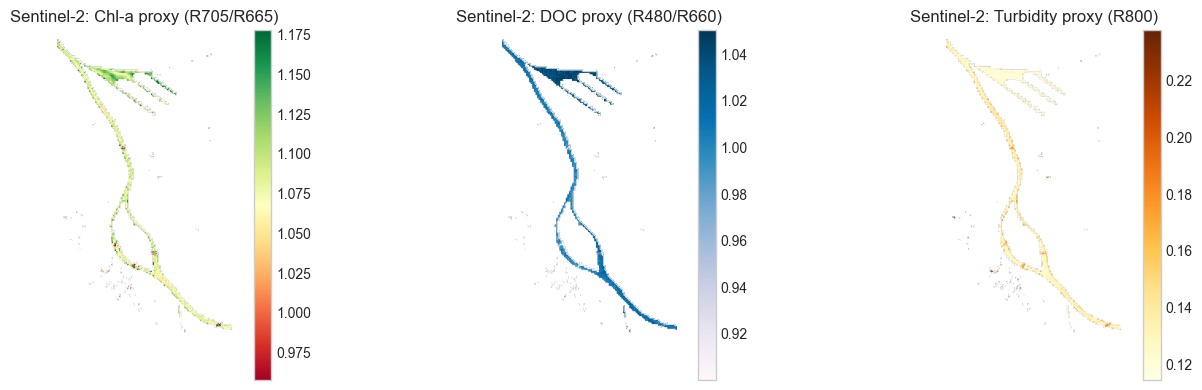

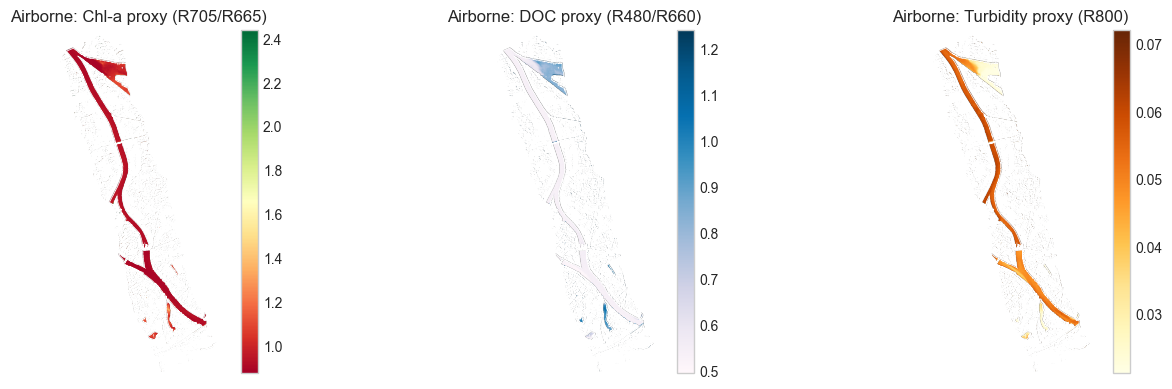

In [31]:
# -------------------------
# Sentinel-2 proxies
# -------------------------
S2_BLUE = s2["B02"].values.astype(np.float32)
S2_GREEN = s2["B03"].values.astype(np.float32)
S2_RED = s2["B04"].values.astype(np.float32)
S2_RE1 = s2["B05"].values.astype(np.float32)
S2_NIR = s2["B8A"].values.astype(np.float32)
S2_SWIR1 = s2["B11"].values.astype(np.float32)
S2_SWIR2 = s2["B12"].values.astype(np.float32)

if np.nanmax(S2_RED) > 2:
    for a in (S2_BLUE, S2_GREEN, S2_RED, S2_RE1, S2_NIR, S2_SWIR1, S2_SWIR2):
        a /= 10000.0

with np.errstate(divide='ignore', invalid='ignore'):
    chl_a_proxy_s2 = safe_div(S2_RE1, S2_RED + 1e-6)
    doc_proxy_s2 = safe_div(S2_BLUE, S2_RED)
    turb_proxy_s2 = S2_NIR.astype(np.float32)

ndwi_s2 = safe_div(S2_GREEN - S2_NIR, S2_GREEN + S2_NIR)
water_mask_s2 = (ndwi_s2 > -0.1) & (S2_NIR < 0.25) & (S2_NIR > 0.0001)

print(f"Sentinel-2 water fraction: {100 * water_mask_s2.mean():.2f}%")

chl_a_map_s2 = np.where(water_mask_s2, chl_a_proxy_s2, np.nan)
doc_map_s2 = np.where(water_mask_s2, doc_proxy_s2, np.nan)
turb_map_s2 = np.where(water_mask_s2, turb_proxy_s2, np.nan)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (arr, ttl, cmap) in enumerate([
    (chl_a_map_s2, "Sentinel-2: Chl-a proxy (R705/R665)", "RdYlGn"),
    (doc_map_s2, "Sentinel-2: DOC proxy (R480/R660)", "PuBu"),
    (turb_map_s2, "Sentinel-2: Turbidity proxy (R800)", "YlOrBr"),
]):
    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        vmin, vmax = np.nanpercentile(vals, [2, 98])
    else:
        vmin, vmax = None, None

    im = ax[i].imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax[i].contour(water_mask_s2, levels=[0.5], colors="white", linewidths=0.5)
    ax[i].set_title(ttl)
    ax[i].axis("off")
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)
plt.tight_layout()
def stretch_band_01(band, p_min=2, p_max=98):
    """Skaluje wartości kanału do zakresu 0-1 dla lepszego wyświetlania."""
    v_min, v_max = np.nanpercentile(band, [p_min, p_max])
    return np.clip((band - v_min) / (v_max - v_min), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (arr, ttl, cmap) in enumerate([
    (chl_a_map_air, "Airborne: Chl-a proxy (R705/R665)", "RdYlGn"),
    (doc_map_air, "Airborne: DOC proxy (R480/R660)", "PuBu"),
    (turb_map_air, "Airborne: Turbidity proxy (R800)", "YlOrBr"),
]):
    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        vmin, vmax = np.nanpercentile(vals, [2, 98])
    else:
        vmin, vmax = None, None

    im = ax[i].imshow(arr[::s, ::s], cmap=cmap, vmin=vmin, vmax=vmax)
    ax[i].contour(water_mask_air[::s, ::s], levels=[0.5], colors="white", linewidths=0.5)
    ax[i].set_title(ttl)
    ax[i].axis("off")
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)
plt.tight_layout()

# RGB
# rgb_s2 = np.dstack([
#     robust_stretch(S2_RED),
#     robust_stretch(S2_GREEN),
#     robust_stretch(S2_BLUE)
# ])

# plt.figure(figsize=(10, 10))
# plt.imshow(rgb_s2)
# plt.title("Sentinel-2: Natural Colors (RGB)")
# plt.axis("off")
# plt.show()

Sentinel-2's 20m spatial resolution is insufficient for this fluvial environment, leading to severe spectral mixing and loss of detail. While the airborne data reveals fine-scale plume structures, Sentinel-2 produces coarse, pixelated results that fail to accurately capture DOC and Turbidity gradients

## Exercise 4: Spectral Angle Mapper (SAM)

In [ ]:
# Defining S-2 bands
S2_SAM_TARGETS_NM = [490, 560, 665, 705, 865, 1610, 2190]
S2_SAM_BAND_KEYS = ["B02", "B03", "B04", "B05", "B8A", "B11", "B12"]

# Spectral library
library_refs = {}
for p in sorted(SPECTRAL_LIBRARY_DIR.glob("*.json")):
    with open(p, "r", encoding="utf-8") as f:
        lib = json.load(f)
    
    if "classes" in lib and isinstance(lib["classes"], dict):
        for cls, rec in lib["classes"].items():
            if "mean" in rec:
                library_refs[cls] = np.array(rec["mean"], dtype=np.float32)
    elif "mean" in lib:
        library_refs[p.stem] = np.array(lib["mean"], dtype=np.float32)

if not library_refs:
    raise RuntimeError(f"Nie znaleziono sygnatur w {SPECTRAL_LIBRARY_DIR}")

print("Classes found:", sorted(list(library_refs.keys())))

# Resampling
ref_s2d = {}
s2_sam_band_idx = [nearest_band_index(wavelengths, wl) for wl in S2_SAM_TARGETS_NM]

for cls, mu in library_refs.items():
    v = np.array([mu[bi] if bi < mu.size else np.nan for bi in s2_sam_band_idx])
    if np.all(np.isfinite(v)):
        ref_s2d[cls] = v

ref_names = sorted(ref_s2d.keys())
R = np.stack([ref_s2d[n] for n in ref_names], axis=0).astype(np.float32)

s2_stack = np.dstack([
    S2_BLUE, S2_GREEN, S2_RED, S2_RE1, S2_NIR, S2_SWIR1, S2_SWIR2
]).astype(np.float32)

Classes found: ['agriculture', 'forest', 'green_areas', 'urban', 'water']


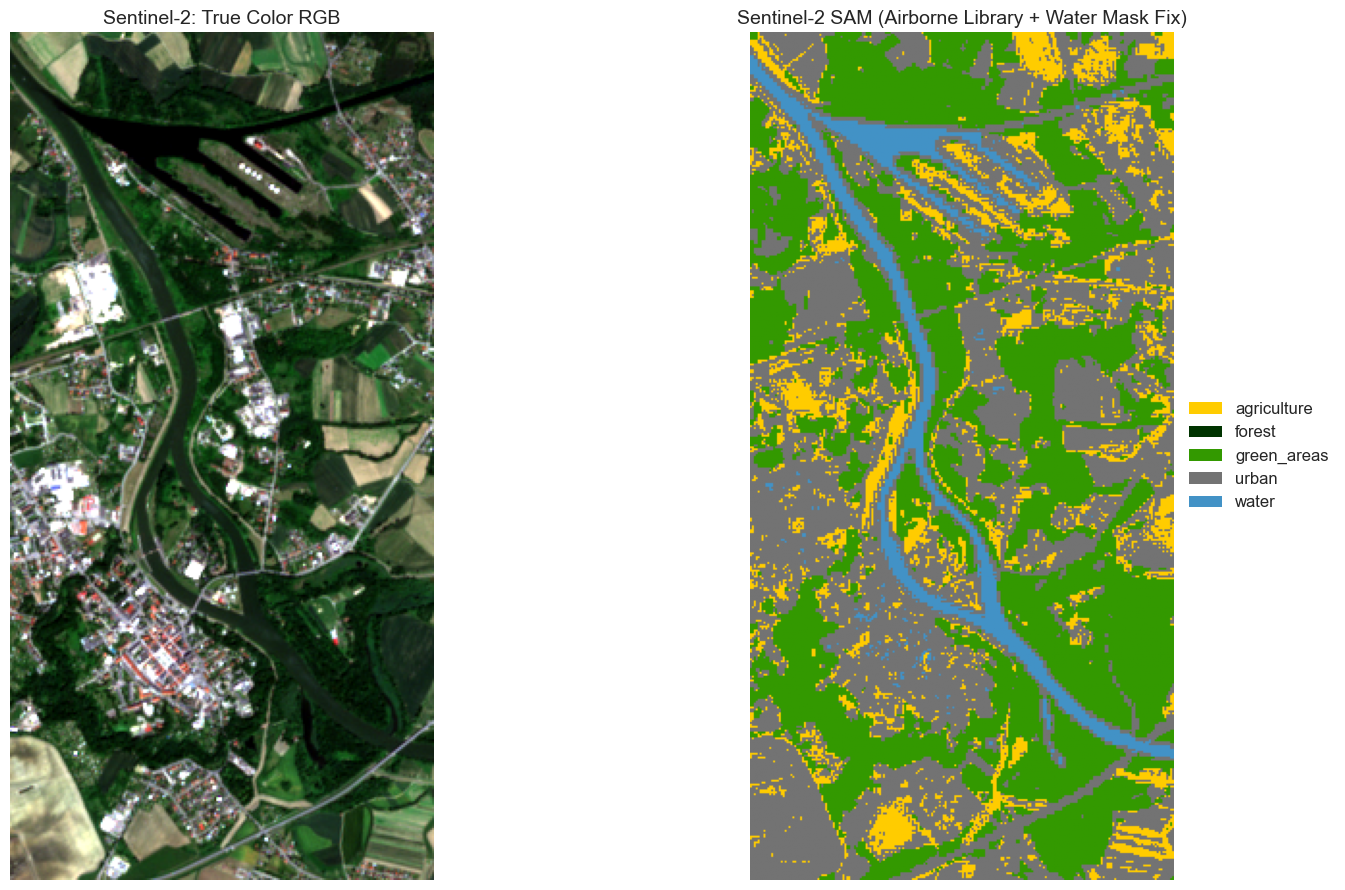

In [ ]:
# SAM function
def run_sam_final(stack, ref_matrix):
    h, w, b = stack.shape
    pixels = stack.reshape(-1, b)
    dot = pixels @ ref_matrix.T
    p_norm = np.linalg.norm(pixels, axis=1, keepdims=True)
    r_norm = np.linalg.norm(ref_matrix, axis=1, keepdims=True).T
    cos_alpha = np.clip(dot / (p_norm @ r_norm + 1e-9), -1.0, 1.0)
    return np.argmin(np.arccos(cos_alpha), axis=1).reshape(h, w)

# classification
raw_sam_map = run_sam_final(s2_stack, R)

# Water mask
final_s2_sam = raw_sam_map.copy()
if 'water' in ref_names:
    water_idx = ref_names.index('water')
    final_s2_sam[water_mask_s2] = water_idx

rgb_s2 = np.dstack([robust_stretch(S2_RED), robust_stretch(S2_GREEN), robust_stretch(S2_BLUE)])

# agriculture, forest, green_areas, urban, water
colors = ['#ffcc00', '#003300', '#339900', '#737373', '#4292c6']
from matplotlib.colors import ListedColormap
cmap_final = ListedColormap(colors)

# RGB
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

# RGB
ax1.imshow(rgb_s2)
ax1.set_title("Sentinel-2: True Color RGB", fontsize=14)
ax1.axis('off')

# SAM
im = ax2.imshow(final_s2_sam, cmap=cmap_final, vmin=0, vmax=len(ref_names)-1)
ax2.set_title("Sentinel-2 SAM (Airborne Library + Water Mask Fix)", fontsize=14)
ax2.axis('off')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=name) for i, name in enumerate(ref_names)]
ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

plt.tight_layout()
plt.show()

The final classification maps almost all classes, and the NDWI water mask significantly improved the output.
However, some errors remain. Green areas are classified correctly, but forests are merged into that class too. 
The agricultural fields are sometimes classified as urban and in urban areas there are few pixels classified as water and agriculture.

This happens because Sentinel-2 has a lower spatial resolution (10–20m), leading to mixed pixels where different land covers blend together. Additionally, SAM only measures the spectral angle and ignores brightness.

In [ ]:
valid_pixels = final_s2_sam[final_s2_sam >= 0]

if valid_pixels.size == 0:
    print("No pixels classified")
else:
    counts = np.bincount(valid_pixels, minlength=len(ref_names))
    percentages = (counts / counts.sum()) * 100

    df_stats = pd.DataFrame({
        "No. of pixels": counts,
        "Share (%)": percentages
    }, index=ref_names)
    
    display(df_stats)

--- Statystyki klasyfikacji Sentinel-2 ---


,Liczba pikseli,Udział (%)
agriculture,11825,12.215909
forest,0,0.000000
green_areas,37658,38.902893
urban,42373,43.773760
water,4944,5.107438


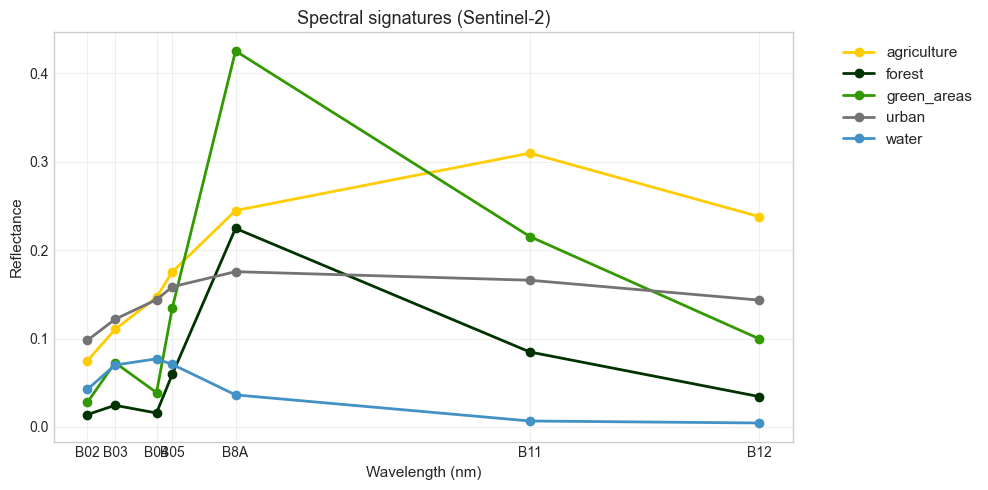

In [46]:
colors = ['#ffcc00', '#003300', '#339900', '#737373', '#4292c6']

plt.figure(figsize=(10, 5))
for i, name in enumerate(ref_names):
    plt.plot(
        S2_SAM_TARGETS_NM, 
        R[i], 
        label=name, 
        color=colors[i % len(colors)], 
        marker='o', 
        linewidth=2, 
        markersize=6
    )

plt.title("Spectral signatures (Sentinel-2)", fontsize=13)
plt.xlabel("Wavelength (nm)", fontsize=11)
plt.ylabel("Reflectance", fontsize=11)

plt.xticks(S2_SAM_TARGETS_NM, S2_SAM_BAND_KEYS)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()